In [1]:
import numpy as np
import mmcfilters
import mmcfilters_notebook_compat as notebook_compat
notebook_compat.install(mmcfilters)
import matplotlib
import math

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16,16)

from IPython import display
from os import listdir
import cv2 as cv


In [2]:
#imgInput = cv.imread("../dat/imgTeste.png", cv.IMREAD_GRAYSCALE)
imgInput = cv.imread("../dat/imgObjetos.png", cv.IMREAD_GRAYSCALE)
#imgInput = cv.imread("../dat/cable.png", cv.IMREAD_GRAYSCALE)

(num_rows, num_cols) = imgInput.shape

#plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
#plt.title('input')

In [3]:
tree = mmcfilters.MorphologicalTree(imgInput, True, 1.5)
dic, attrs = mmcfilters.Attribute.computeAttributes(tree, [mmcfilters.Attribute.Type.BOX_HEIGHT])
attr = attrs[:, dic['BOX_HEIGHT']]

In [4]:
deltaMSER=19
primitives = mmcfilters.AttributeOpeningPrimitivesFamily(tree, attr, num_rows, deltaMSER)

In [5]:
thresholds = primitives.getThresholdsPrimitive()
numPrimitesForDisplay = 8
thrs = np.array(thresholds, dtype=int)[np.linspace(0, len(thresholds)-1, numPrimitesForDisplay, dtype=int)]
primitives.numPrimitives, len(thresholds), thrs

(21671, 169, array([  1,  25,  49,  74, 102, 139, 204, 863]))

Text(0.5, 1.0, 'restOfImage')

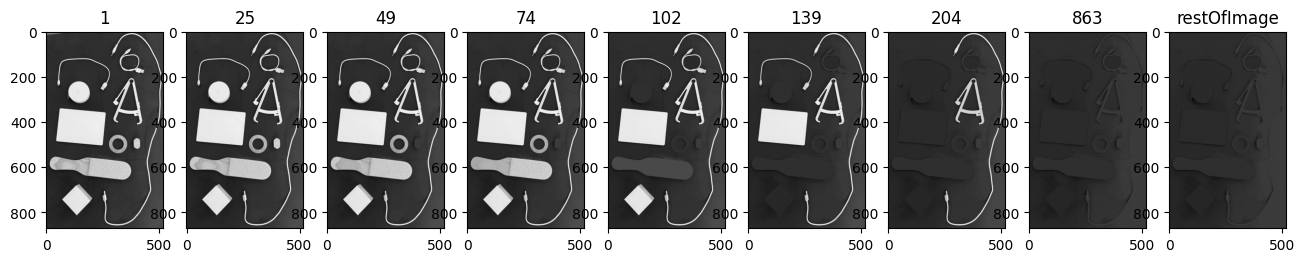

In [6]:
i = 0
for threshold in thrs:
    i += 1
    plt.subplot(1,len(thrs)+1, i)
    primitiva = primitives.getPrimitive(threshold) 
    plt.imshow(primitiva.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
    plt.title(str(int(threshold)))

rest = primitives.restOfImage
plt.subplot(1,len(thrs)+1, len(thrs)+1)
plt.imshow(rest.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('restOfImage')

Text(0.5, 1.0, 'residual filter (without rest)')

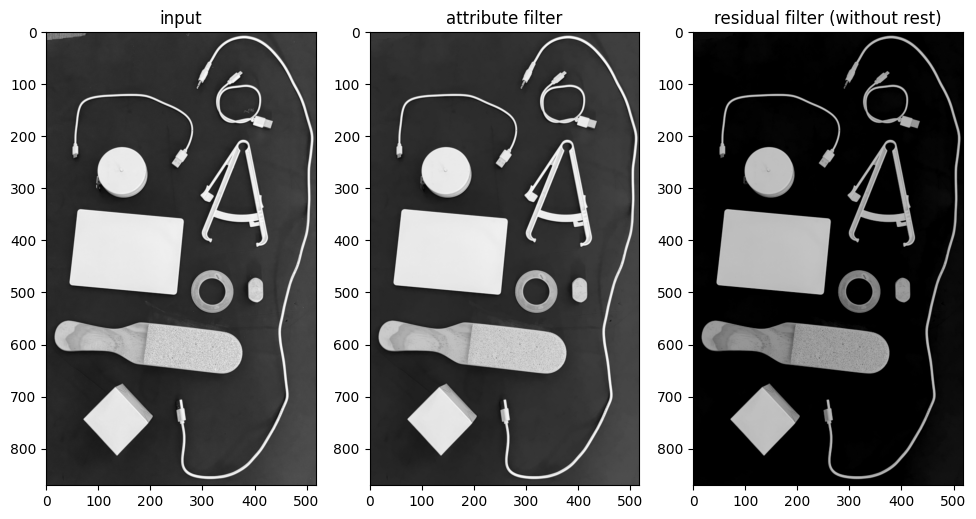

In [8]:
attribute = attrs[:, dic['BOX_HEIGHT']]
threshold = 20

filter = mmcfilters.AttributeFilters(tree)
imgAttrFilter = filter.filteringSubtractiveRule(attribute > threshold)
imgResFilter = primitives.getPrimitive(threshold)
imgPrimitiveOnly = np.clip(
    imgResFilter.astype(np.int16) - rest.astype(np.int16),
    0,
    255,
).astype(np.uint8)


plt.subplot(1,4, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,4, 2)
plt.imshow(imgAttrFilter.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter')

plt.subplot(1,4, 3)
plt.imshow(imgPrimitiveOnly.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('residual filter (without rest)')

plt.subplot(1,4, 4)
plt.imshow(rest.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('restOfImage')

Text(0.5, 1.0, 'filter')

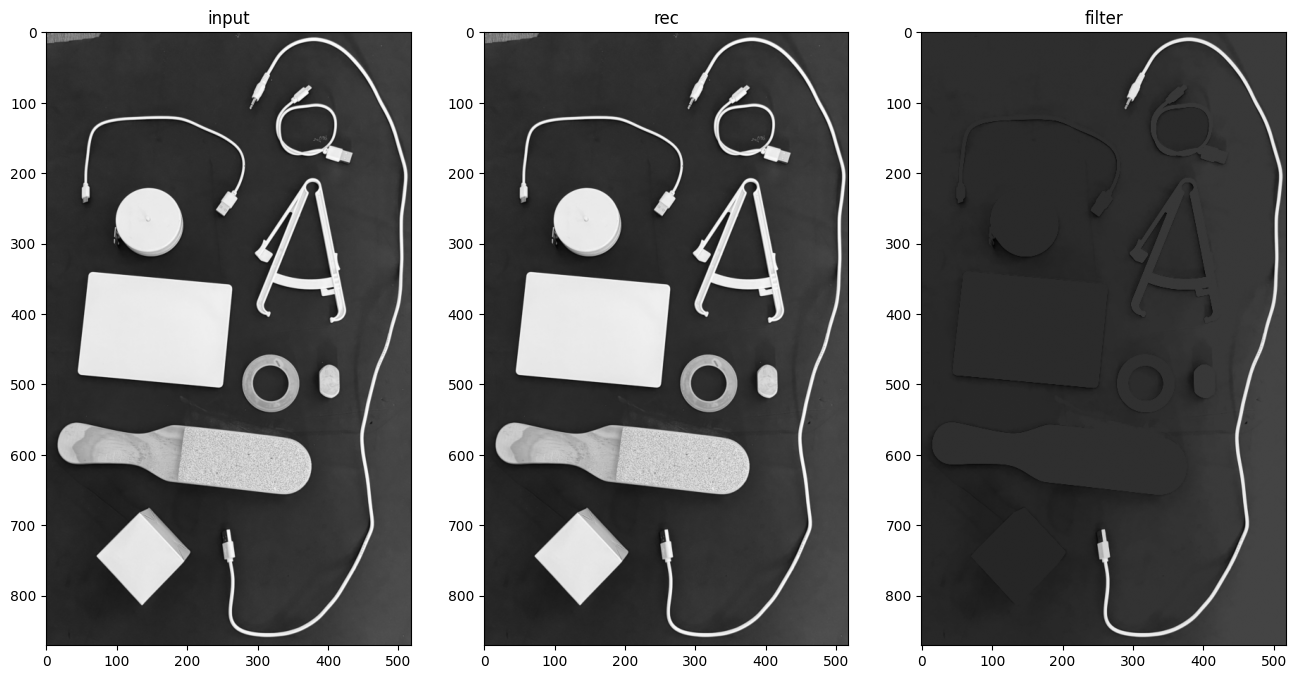

In [9]:
imgrec = tree.reconstructionImage() 
imgfilter = filter.filteringSubtractiveRule(attr > 500)

plt.subplot(1,3, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,3, 2)
plt.imshow(imgrec.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('rec')

plt.subplot(1,3, 3)
plt.imshow(imgfilter.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('filter')


#np.sum(imgInput.ravel() - imgrec)

Text(0.5, 1.0, 'associated')

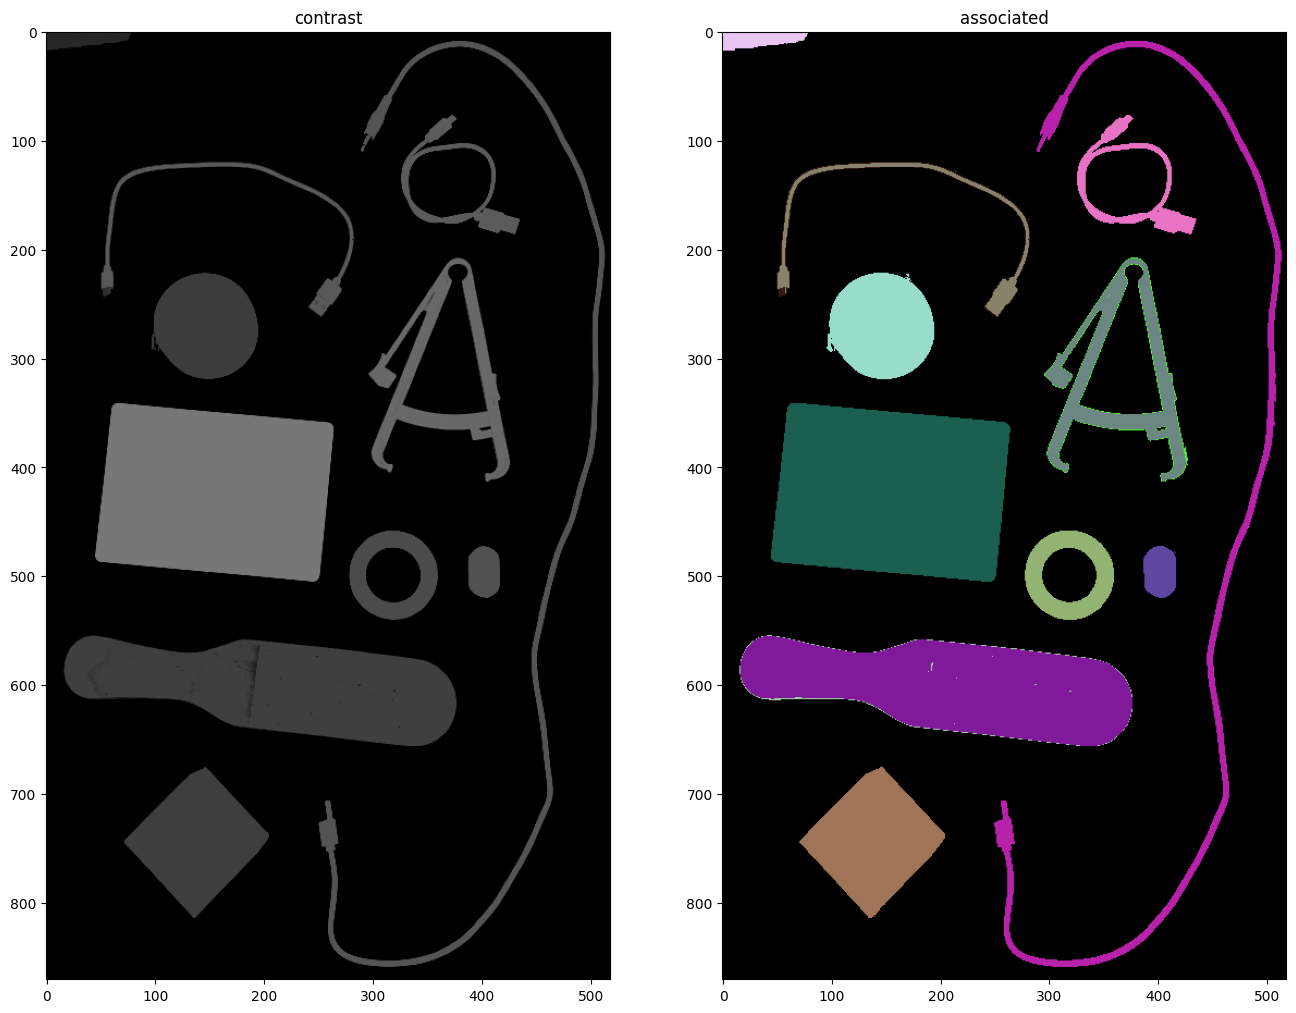

In [10]:
uao = mmcfilters.UltimateAttributeOpening(tree, attr)
uao.executeWithMSER(num_rows, deltaMSER)
imgContrast_rt = uao.getMaxContrastImage()
imgAssociatedColored_rt = uao.getAssociatedColoredImage()

plt.subplot(1,2,1)
plt.imshow(imgContrast_rt.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('contrast')

plt.subplot(1,2,2)
plt.imshow(imgAssociatedColored_rt.reshape(num_rows, num_cols, 3), vmax=255, vmin=0)
plt.title('associated')

Text(0.5, 1.0, 'associated')

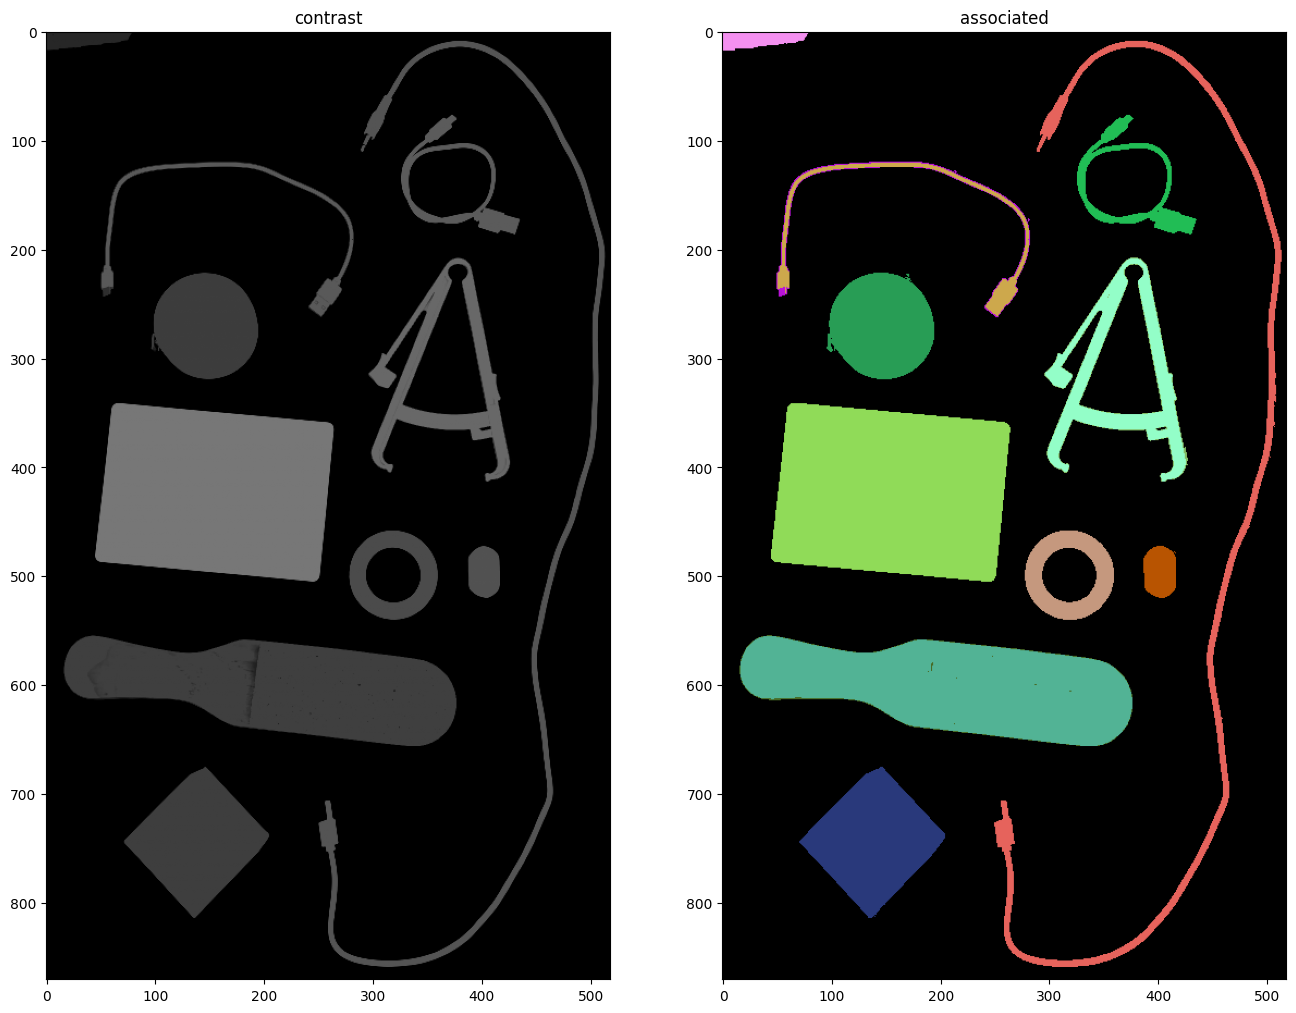

In [11]:
uao = mmcfilters.UltimateAttributeOpening(tree, attr)

uao.executeWithMSER( num_rows, deltaMSER )
imgAssociated = uao.getAssociatedColoredImage()
imgContrast = uao.getMaxContrastImage()

#import random
#colors = [ [random.randint(0, 255) for _ in range(3)] for _ in range(0, np.max(imgAssociated)+1)]
#imgRGBContrast = [(0,0,0) if p == 0 else colors[p] for p in imgAssociated]

plt.subplot(1,2,1)
plt.imshow(imgContrast.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('contrast')

plt.subplot(1,2,2)
plt.imshow(np.array(imgAssociated).reshape(num_rows, num_cols, 3), vmax=255, vmin=0)
plt.title('associated')

In [12]:
np.sum(imgContrast_rt - imgContrast)

np.uint64(0)

Text(0.5, 1.0, 'associated')

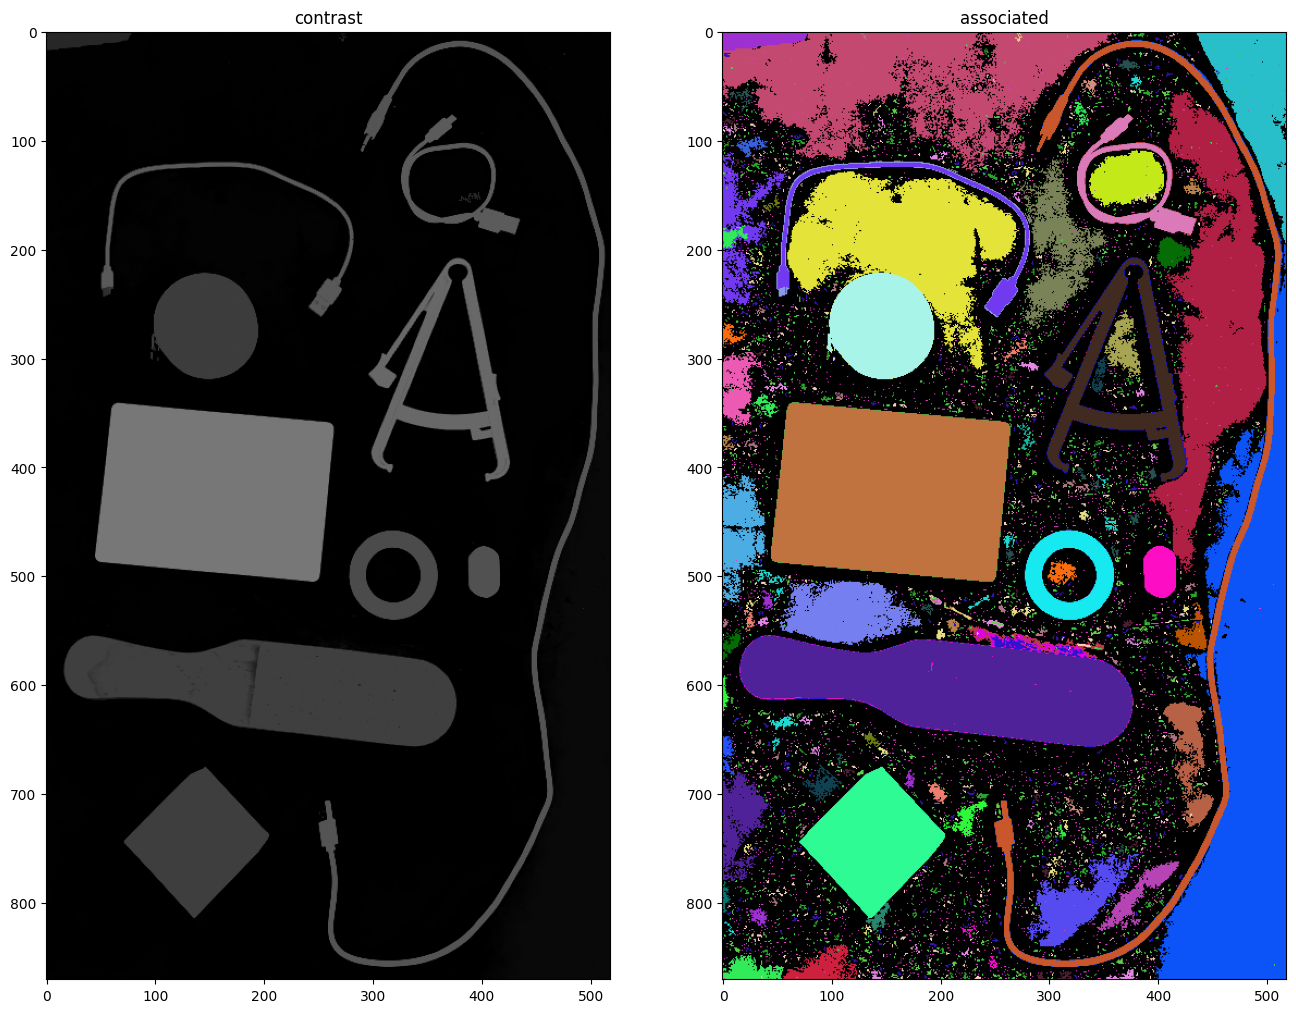

In [13]:
imgInput = cv.imread("../dat/imgObjetos.png", cv.IMREAD_GRAYSCALE)
(num_rows, num_cols) = imgInput.shape
tree = mmcfilters.MorphologicalTree(imgInput, True, 1.5)
dic, attrs = mmcfilters.Attribute.computeAttributes(tree, [mmcfilters.Attribute.Type.BOX_HEIGHT])

uao = mmcfilters.UltimateAttributeOpening(tree, attrs[:, dic['BOX_HEIGHT']])
uao.execute(num_rows - 1)
imgContrast = uao.getMaxContrastImage()
imgAssociatedColored = uao.getAssociatedColoredImage()

plt.subplot(1,2,1)
plt.imshow(imgContrast.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('contrast')

plt.subplot(1,2,2)
plt.imshow(imgAssociatedColored.reshape(num_rows, num_cols, 3), vmax=255, vmin=0)
plt.title('associated')

Text(0.5, 1.0, 'associated')

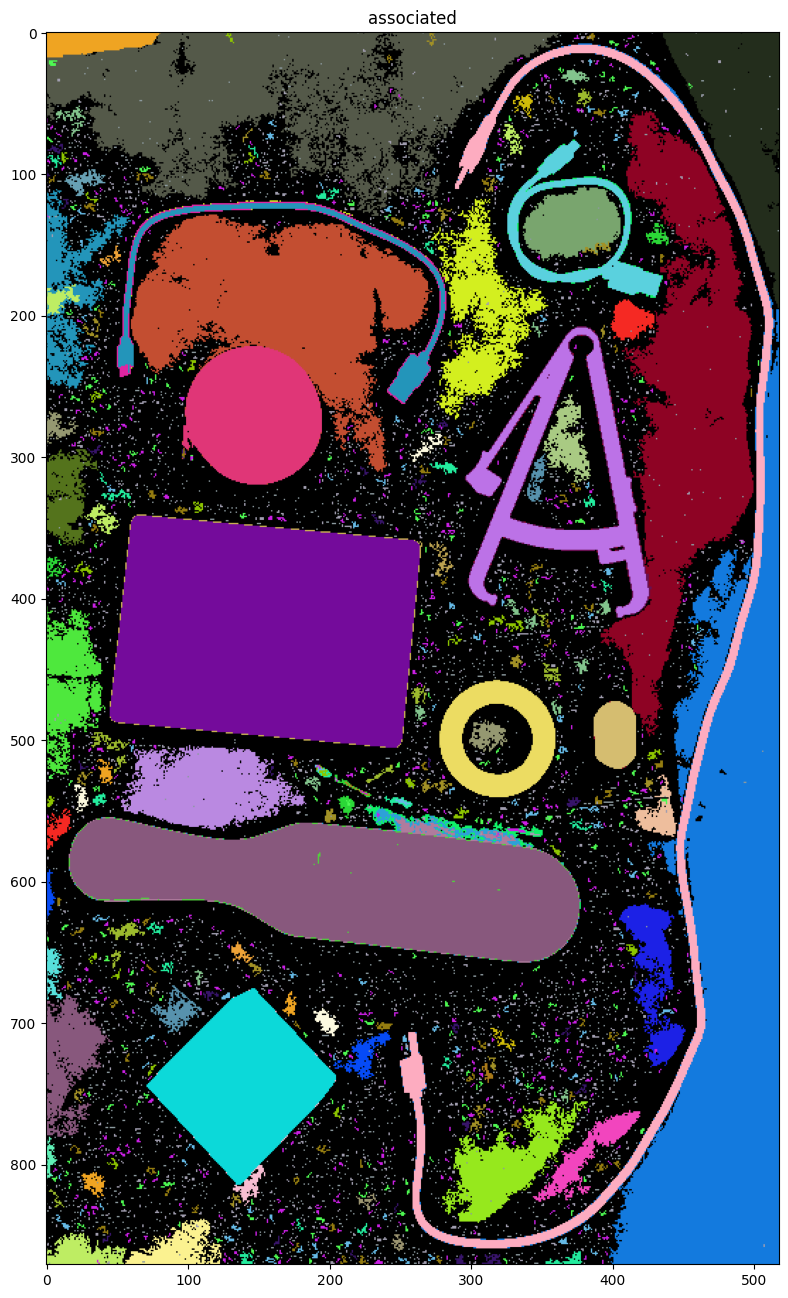

In [14]:
imgAssociated = uao.getAssociatedImage().ravel()

import random
colors = [[random.randint(0, 255) for _ in range(3)] for _ in range(0, int(np.max(imgAssociated)) + 1)]
imgRGBContrast = [(0, 0, 0) if p == 0 else colors[int(p)] for p in imgAssociated]

plt.imshow(np.array(imgRGBContrast).reshape(num_rows, num_cols, 3), vmax=255, vmin=0)
plt.title('associated')

Text(0.5, 1.0, 'associated')

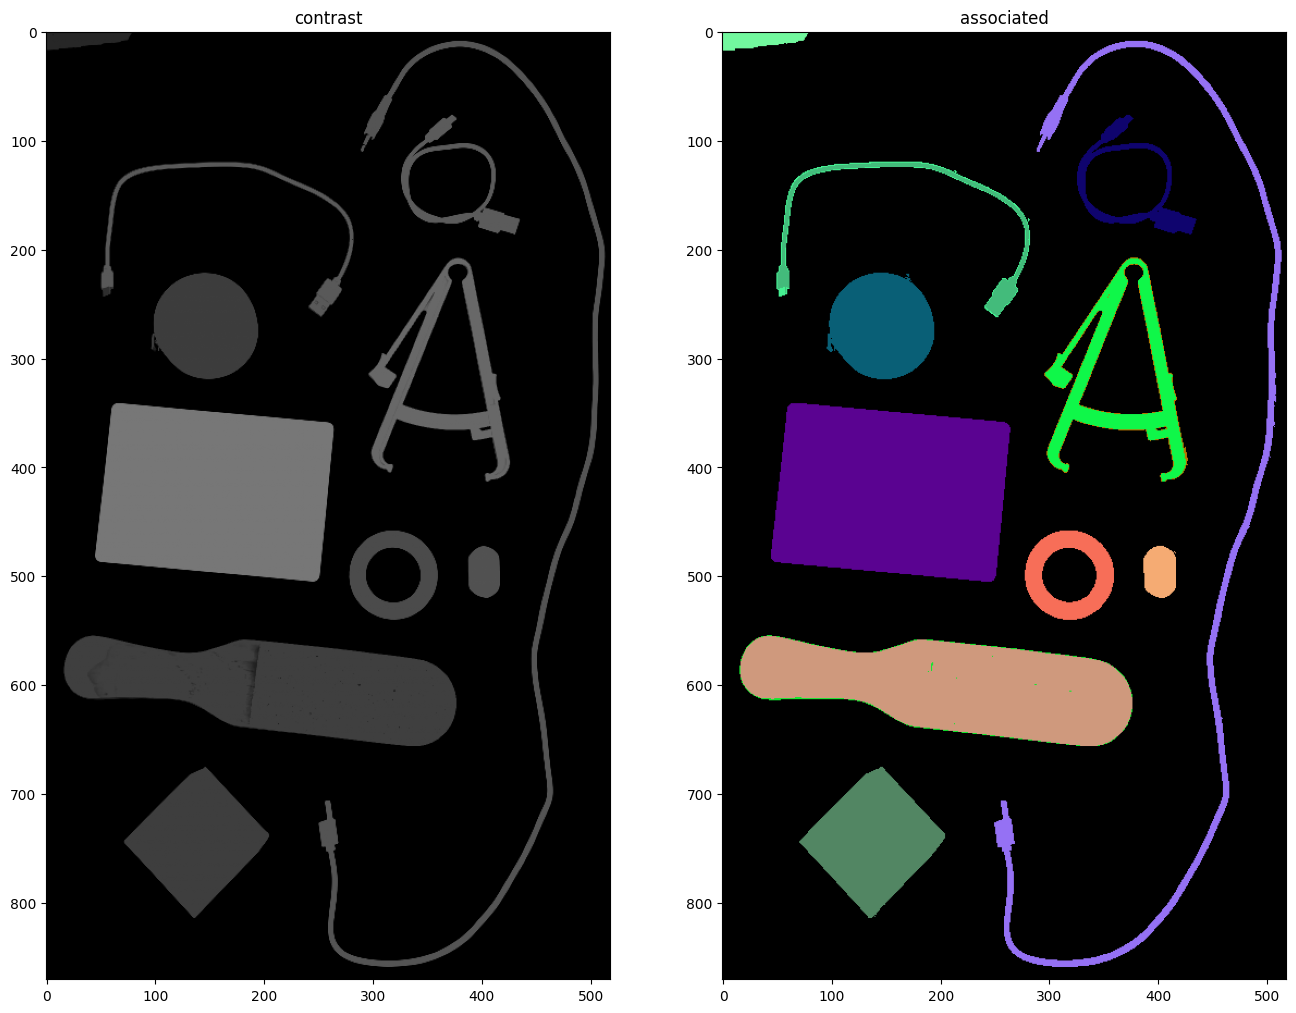

In [15]:
maxCriterion = num_rows
deltaMSER = 20

uao.executeWithMSER( int(maxCriterion), deltaMSER )
imgContrast = uao.getMaxContrastImage()
imgAssociatedColored = uao.getAssociatedColoredImage()

plt.subplot(1,2,1)
plt.imshow(imgContrast.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('contrast')

plt.subplot(1,2,2)
plt.imshow(imgAssociatedColored.reshape(num_rows, num_cols, 3), vmax=255, vmin=0)
plt.title('associated')

In [16]:
np.min(imgAssociatedColored), np.max(imgAssociatedColored)

(np.uint8(0), np.uint8(248))

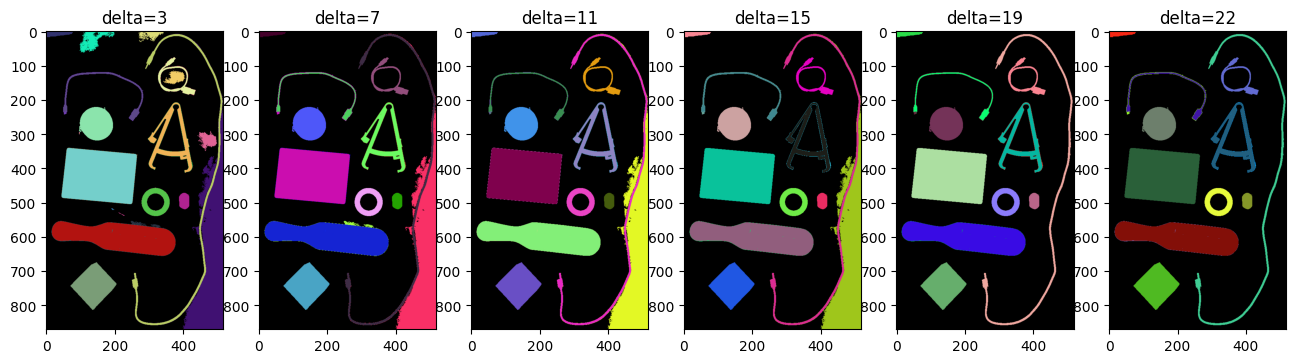

In [17]:
uao = mmcfilters.UltimateAttributeOpening(tree, attrs[:,dic['BOX_HEIGHT']])
maxCriterion = num_rows
line = 1
for i in range(1, 6+1):
    deltaMSER = int(i*3.8)
    uao.executeWithMSER( int(maxCriterion), deltaMSER )
    imgAssociatedColored = uao.getAssociatedColoredImage()
        
    plt.subplot(line,6, i)
    plt.imshow(imgAssociatedColored.reshape(num_rows, num_cols, 3), vmax=255, vmin=0)
    plt.title('delta=' + str(deltaMSER))